# Feeding on a food grid

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

The assays so far gave the larvae nothing to eat. This one gives them a substrate they are standing
on, and asks the other half of the foraging question : not *where do you go*, but **what do you do
when you are already on food**.

The arena is a 20 mm square whose entire floor is a **food grid** - a lattice of cells, each holding
a small amount of food that the animals deplete as they feed. Feeding and crawling are mutually
exclusive in the model : the intermittency module switches an animal between crawling, pausing and
feeding, and while it feeds it does not advance. What comes out is a time budget and a consumption
curve.

**No energetics here.** The larvae use the `feeder` model, which has a feeder module and no
Dynamic Energy Budget at all. Nothing metabolises what is eaten, nothing grows, and there are no
rover/sitter phenotypes - the amount consumed is simply counted. That keeps the assay about
behavior : how the time is split, and how much food that split brings in.

**What you will be able to do afterwards**

- Run a feeding experiment on a depletable substrate.
- Read how much each animal ate, over time and in total.
- Read the time budget of the intermittency module : crawling, pausing, feeding.
- Render the experiment to a video in which the food visibly disappears.

**Prerequisites** : [Free exploration](free_exploration.ipynb). The locomotion is the same; the
feeder is new.

**Cost** : the experiment is 10 simulated minutes with 20 larvae - a few minutes of compute. The
video repeats the run with rendering on, so it roughly doubles that when enabled.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIMULATION` | `True` | the experiment itself, and therefore every figure below |
| `SAVE_VIDEO` | `True` | a second, rendered run that writes the depletion video |

## Setup

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

import larvaworld
from larvaworld.lib import reg
from larvaworld.lib.sim.single_run import ExpRun

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_SIMULATION = True  # the point of this notebook; a few minutes of compute
SAVE_VIDEO = True  # a second, rendered run that writes the depletion video

EXPERIMENT = "food_grid"
N = 20  # larvae; the stored experiment's duration and timestep are left untouched

# Playback speed of the saved video. One frame is written per simulation tick,
# so the clip lasts Nticks * dt / VIDEO_SPEED seconds: 20 compresses the ten
# simulated minutes into about half a minute.
VIDEO_SPEED = 20

MEDIA_DIR = "./media/simulated_experiments"
plot_dir = f"{MEDIA_DIR}/{EXPERIMENT}"

Initializing larvaworld registry


Registry configured!


## Section 1 : The experiment

`food_grid` is a small arena that is entirely food. There are no discrete patches to find and no
odor to follow - every position is as good as every other, so the only thing that varies is what the
animal chooses to do with its time.

In [2]:
conf = reg.conf.Exp.getID(EXPERIMENT)
env = conf.env_params

print(f"Experiment : {EXPERIMENT}")
print(f"  duration : {conf.duration} min   timestep : {conf.dt} s")
print(
    f"  arena    : {env.arena.geometry}, {[round(x * 1000) for x in env.arena.dims]} mm"
)

sources = env.food_params.source_units
if sources:
    print("  odor sources :")
    for sid, s in sources.items():
        pos_mm = [round(v * 1000, 1) for v in s.pos]
        print(
            f"     {sid:5s} at {pos_mm} mm, odor {s.odor.id!r} "
            f"(intensity {s.odor.intensity}, spread {s.odor.spread:.3f})"
        )
    print(f"  odorscape : {env.odorscape.odorscape}")
else:
    print("  odor sources : none")

for gid, g in conf.larva_groups.items():
    dis = g.distribution
    print(
        f"  larva group {gid!r} : model {g.model if isinstance(g.model, str) else '(inline)'}, "
        f"N={dis.N} placed {dis.mode} around {[round(v * 1000) for v in dis.loc]} mm"
    )

Experiment : food_grid
  duration : 10.0 min   timestep : 0.1 s
  arena    : rectangular, [20, 20] mm
  odor sources : none
  larva group 'feeder' : model feeder, N=5 placed uniform around [0, 0] mm


The food grid itself is the part worth reading. It covers the arena with a lattice of cells, each
starting at `initial_value`, and every feeding event removes some of it from the cell the animal is
standing on. The grid is drawn from **green** when a cell is full to **white** when it is empty,
which is what makes the depletion visible in the video further down.

In [3]:
grid = conf.env_params.food_params.food_grid

print("Food grid :")
print(f"  resolution    : {grid.grid_dims[0]} x {grid.grid_dims[1]} cells")
print(f"  food per cell : {grid.initial_value}")
print(f"  colour        : {grid.color} when full, white when empty")
print(f"  substrate     : quality {grid.substrate.quality}")

Food grid :
  resolution    : 51 x 51 cells
  food per cell : 1e-06
  colour        : green when full, white when empty
  substrate     : quality 1.0


The animals use the `feeder` model. Its brain has a feeder module and an intermittency module, and
crucially **no energetics** : nothing digests, nothing grows.

In [4]:
gID = conf.larva_groups.keylist[0]
m = reg.conf.Model.getID(conf.larva_groups[gID].model)

print(f"Model {conf.larva_groups[gID].model!r} :")
for k, v in m.brain.items():
    if isinstance(v, dict) and "mode" in v:
        print(f"  {k:14s} {v.mode}")
print(f"  energetics     : {m.energetics}")
print()
print(f"Exploration-exploitation balance (EEB) : {m.brain.intermitter.EEB}")
print("  0 = never feed, 1 = always feed; it sets how the intermitter splits the time.")

Model 'feeder' :
  crawler        realistic
  interference   phasic
  turner         neural
  intermitter    default
  feeder         default
  energetics     : None

Exploration-exploitation balance (EEB) : 0.5
  0 = never feed, 1 = always feed; it sets how the intermitter splits the time.


The experiment also asks for its bouts to be annotated after the run, which is what lets the
ethogram further down draw the crawl and pause epochs.

In [5]:
enr = conf.enrichment
print("Metrics computed after the run :")
print(f"  processing : {enr.proc_keys}")
print(f"  annotation : {enr.anot_keys}")

Metrics computed after the run :
  processing : ['spatial', 'angular', 'source']
  annotation : ['bout_detection', 'bout_distribution']


## Section 2 : Running it

In [6]:
r = ExpRun(experiment=EXPERIMENT, N=N)

print(
    f"{EXPERIMENT!r} : {r.p.duration} min at dt={r.p.dt} s  ->  {r.p.Nsteps} timesteps"
)
print(f"  {r.p.larva_groups[r.p.larva_groups.keylist[0]].distribution.N} larvae")

'food_grid' : 10.0 min at dt=0.1 s  ->  6000 timesteps
  20 larvae


In [7]:
d = None
if RUN_SIMULATION:
    r.simulate()
    d = r.datasets[0]
    print(f"{d.id} : {d.config.N} larvae, stored at {d.dir}")
else:
    print("Set RUN_SIMULATION = True to run the experiment.")

--- Simulation food_grid_20 initialized!--- 
--- Simulation food_grid_20 : Generating agent groups!--- 



Run time: 0:01:37.432447
Simulation finished
--- Simulation food_grid_20 completed in 98 seconds!--- 
--- Enriching dataset feeder ---
Vector orientations are already computed. If you want to recompute them, set recompute to True


Angular analysis complete.
Spatial analysis complete.


Turn annotation complete.


Crawl annotation complete.
Patch residency annotation complete.
Chunk dictionaries stored.


Completed bout detection.
Completed bout detection.


Fitted pooled epoch durations.
Completed Lturn bout distribution analysis.
Completed Rturn bout distribution analysis.
Completed Lturn_dur bout distribution analysis.
Completed Rturn_dur bout distribution analysis.
Failed to complete Lturn_amp bout distribution analysis.
Completed Rturn_amp bout distribution analysis.
Completed turn_dur bout distribution analysis.
Failed to complete turn_amp bout distribution analysis.
Failed to complete turn_vel_max bout distribution analysis.
Completed vel_minima bout distribution analysis.
Completed vel_maxima bout distribution analysis.
Completed stride bout distribution analysis.
Completed exec bout distribution analysis.
Completed run_count bout distribution analysis.
Completed stride_Dor bout distribution analysis.
Completed stride_dur bout distribution analysis.
Completed stride_dst bout distribution analysis.
Completed stride_idx bout distribution analysis.
Completed run_dur bout distribution analysis.
Completed run_dst bout distribution analy

--- Dataset feeder enriched ---
--------------------------------


***** Dataset feeder stored.-----
Simulation food_grid_20 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20


feeder : 20 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/data/feeder


## Section 3 : How much was eaten

`amount_eaten` is recorded per animal at every timestep, so it exists both as a cumulative
timeseries and as a final value per larva. Since nothing metabolises it, it is a plain count of what
the feeder took out of the grid.

In [8]:
if d is not None:
    e = d.e
    cols = [
        "amount_eaten",
        "num_feeds",
        "num_feedchains",
        "successful_feeds",
        "failed_feeds",
    ]
    display(e[[c for c in cols if c in e.columns]].describe().round(5))

,amount_eaten,num_feeds,num_feedchains,successful_feeds,failed_feeds
count,20.00000,20.00000,20.00000,20.0000,20.00000
mean,0.08346,820.35000,485.65000,667.7000,152.65000
std,0.00445,20.77771,12.25293,35.6313,17.30614
min,0.07575,794.00000,466.00000,606.0000,121.00000
25%,0.08038,807.00000,477.50000,643.0000,144.00000
50%,0.08363,815.50000,485.50000,669.0000,151.50000
75%,0.08534,829.75000,491.00000,682.7500,159.75000
max,0.09400,873.00000,509.00000,752.0000,191.00000


`num_feeds` counts individual feeding motions and `num_feedchains` the uninterrupted runs of them -
the feeding equivalent of a stridechain.

`failed_feeds` is the interesting one. It counts feeding motions made while the animal was **not on
food**, and a grid cell stops counting as food once it has been emptied. On a substrate that starts
as food everywhere, a failed feed can therefore only mean one thing : the animal tried to eat a cell
it had already exhausted. It is depletion showing up in the numbers rather than in the picture.

## Section 4 : The time budget

The intermittency module puts an animal in one of three states at every timestep, and records it as
`behavioral_state` : **exec** while crawling, **pause** while stopped, and **feed** while feeding.
Counting those states is the most direct statement of how a larva spent the experiment.

In [9]:
STATE_LABELS = {"exec": "crawling", "pause": "pausing", "feed": "feeding"}

budget = None
if d is not None:
    beh = d.s["behavioral_state"].dropna()
    budget = (
        beh.groupby(level="AgentID")
        .value_counts(normalize=True)
        .unstack(fill_value=0.0)
        .reindex(columns=["exec", "pause", "feed"], fill_value=0.0)
        .rename(columns=STATE_LABELS)
        * 100
    )
    display(budget.describe().round(1))

behavioral_state,crawling,pausing,feeding
count,20.0,20.0,20.0
mean,30.8,0.8,68.4
std,1.7,0.4,1.7
min,26.8,0.3,66.1
25%,29.9,0.6,67.3
50%,31.1,0.7,67.9
75%,32.0,1.0,69.2
max,33.1,1.8,72.7


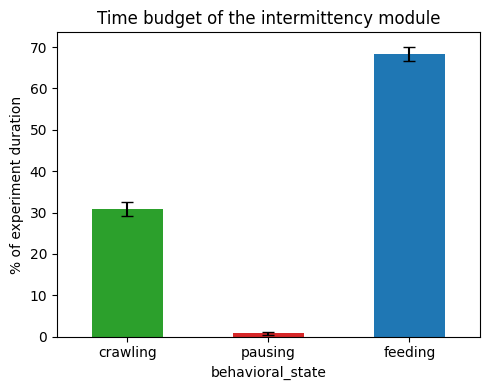

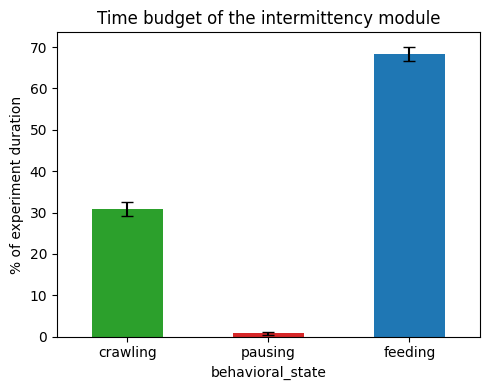

In [10]:
if budget is not None:
    ax = budget.mean().plot.bar(
        color=["tab:green", "tab:red", "tab:blue"],
        figsize=(5, 4),
        rot=0,
        yerr=budget.std(),
        capsize=4,
    )
    ax.set_ylabel("% of experiment duration")
    ax.set_title("Time budget of the intermittency module")
    ax.figure.tight_layout()
    display(ax.figure)

On a substrate that is food everywhere, an animal has no reason to leave, so the balance is heavily
towards feeding - the `feeder` model's EEB printed above is what sets it. Pausing barely appears,
because a pause competes with feeding for the same non-crawling time.

## Section 5 : The analysis

Every stored experiment knows which figures belong to it. `ExpRun.analyze()` looks the experiment up,
runs the plots registered for that kind of assay, writes them next to the datasets, and returns them
grouped by topic in `r.figs`. Nothing has to be chosen by hand.

In [11]:
if RUN_SIMULATION:
    r.analyze()
    print("Figure groups produced :")
    for gname, group in r.figs.items():
        print(f"  {gname:12s} {list(group)}")
    print()
    print(f"All of them were also written to {r.plot_dir}")

Plot comparative_trajectories_default.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/traj\comparative_trajectories_default.pdf


Plot aligned2origin.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/traj\aligned2origin.pdf


Plot runsNpauses.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/general\runsNpauses.pdf
Plot food intake (raw).pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/intake\food intake (raw).pdf


Plot food intake (filtered).pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/intake\food intake (filtered).pdf
Plot timeplots_x1.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/intake\timeplots_x1.pdf
Plot food intake (barplot).pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/intake\food intake (barplot).pdf


Plot ethogram.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots/intake\ethogram.pdf
Figure groups produced :
  traj         ['trajectories', 'aligned2origin']
  general      ['epochs']
  intake       ['food intake (raw)', 'food intake (filtered)', 'pathlength', 'food intake (barplot)', 'ethogram']

All of them were also written to C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/food_grid/food_grid_20/plots


`r.figs` holds the figure objects themselves, so they can be shown here one group at a time.

In [12]:
def show(group):
    """Display every figure of one analysis group."""
    if not RUN_SIMULATION or group not in r.figs:
        return
    for name, fig in r.figs[group].items():
        print(name)
        display(fig)

### Food intake and the ethogram

The registered analysis of this experiment. The two intake curves are the cumulative amount eaten
over time, raw and low-pass filtered; the barplot is the final amount per group; the pathlength says
how far the animals travelled while doing it.

The **ethogram** is the per-animal picture of the time budget above : one row per larva, with its
crawling epochs in green and its pauses in red, next to the left and right turns. Read it alongside
the bar chart - the bar chart says how much, the ethogram says when.

food intake (raw)


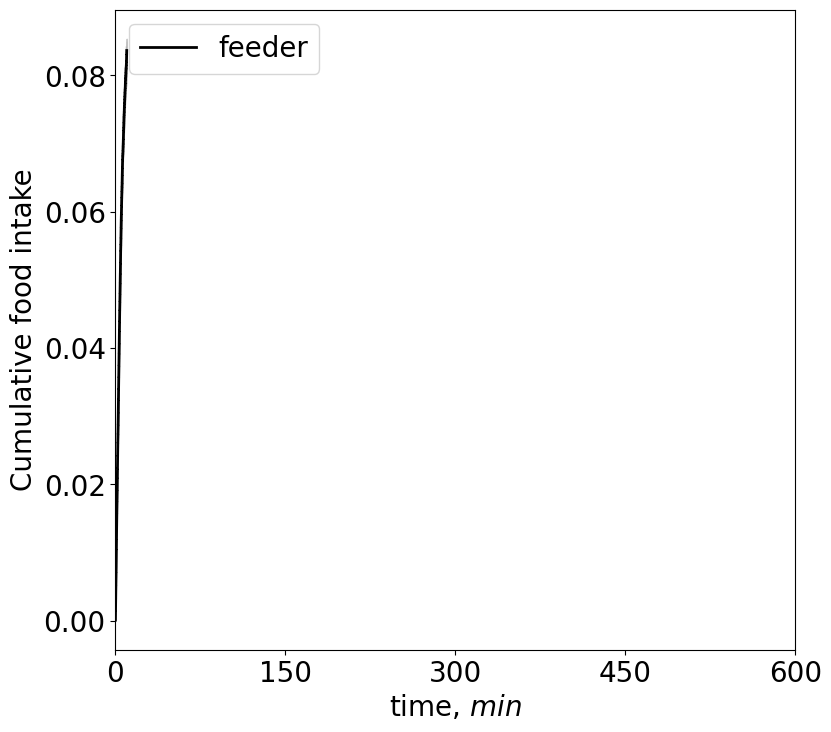

food intake (filtered)


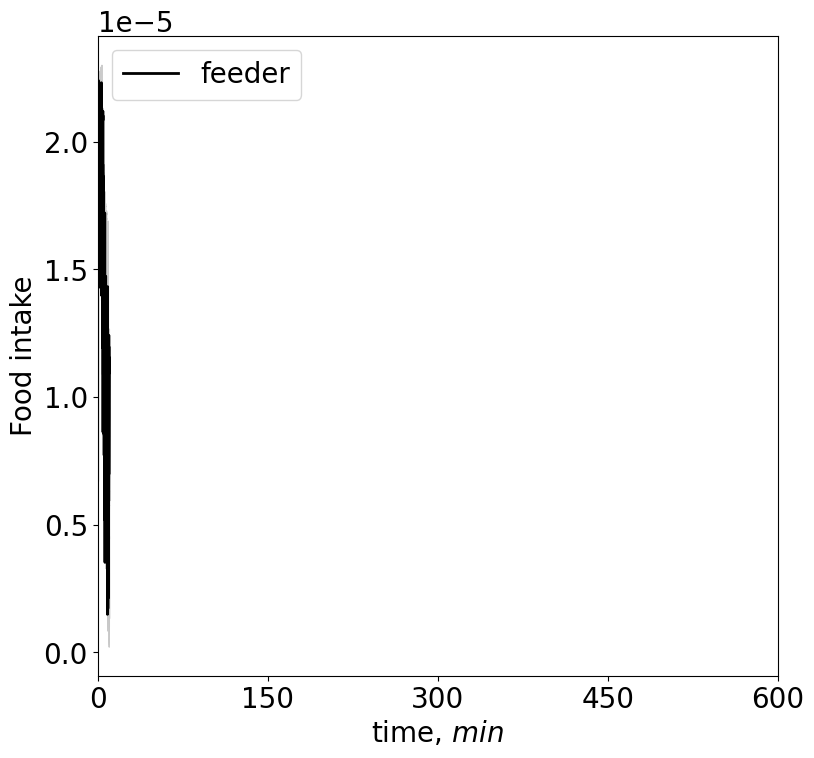

pathlength


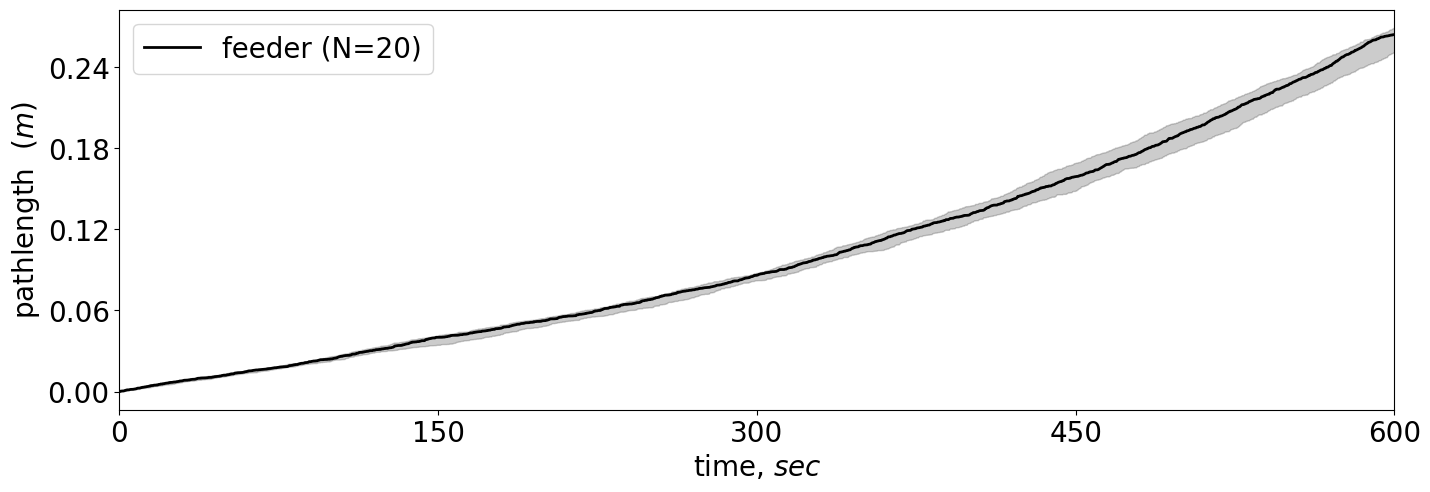

food intake (barplot)


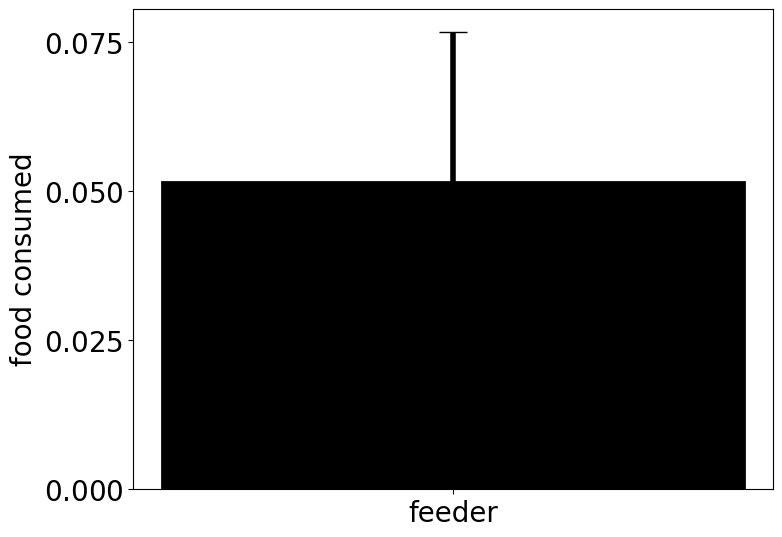

ethogram


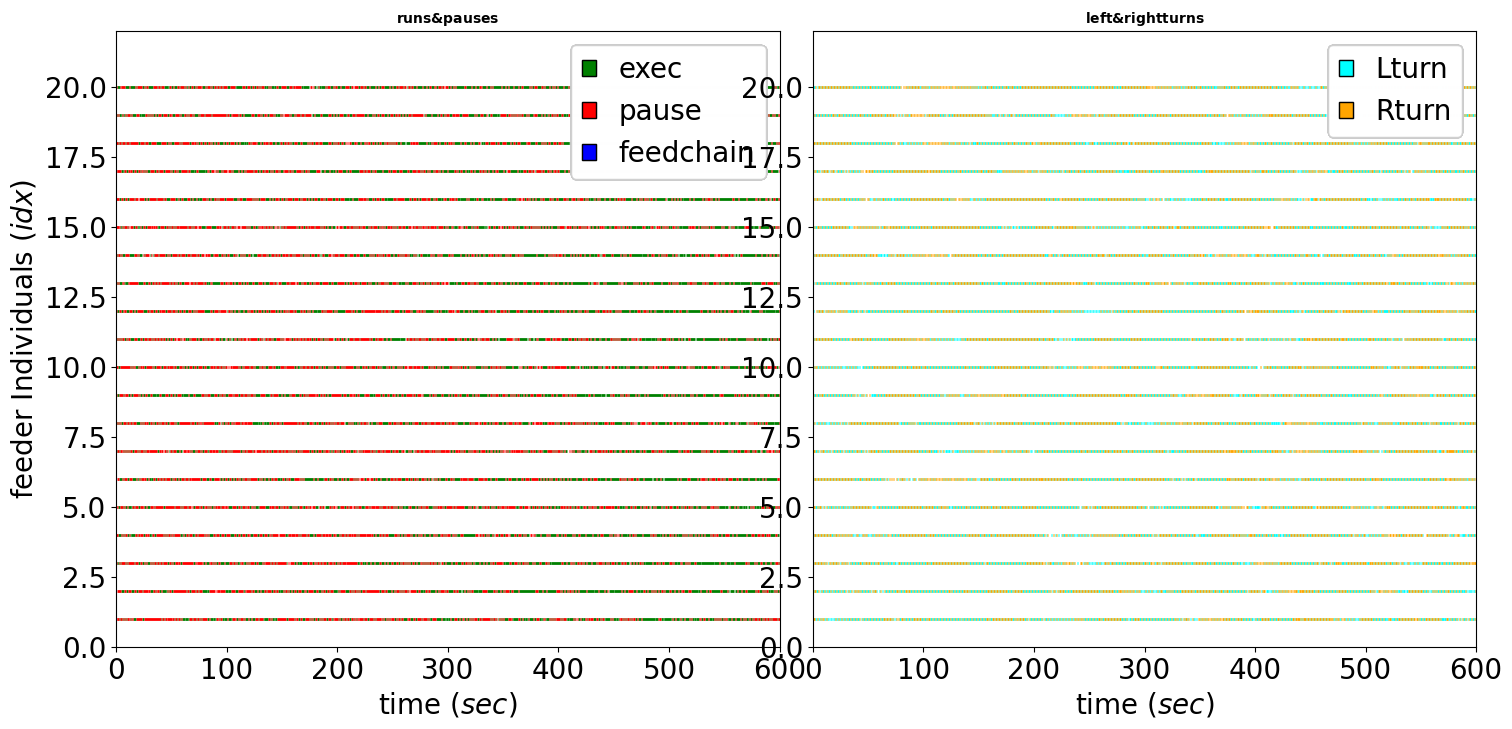

In [13]:
show("intake")

### The paths

Where the animals went while feeding. On a uniform substrate the tracks stay short, because a
feeding larva is not moving.

trajectories


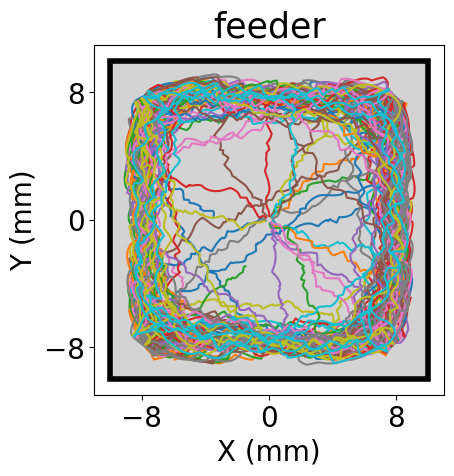

aligned2origin


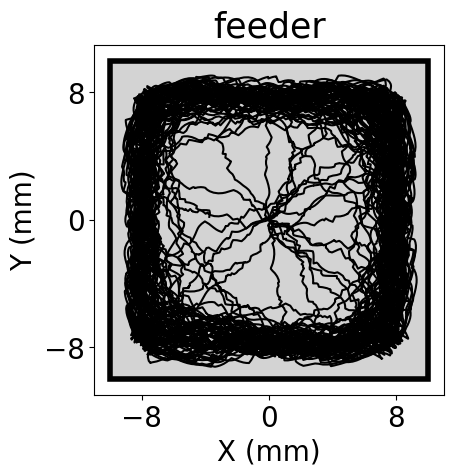

In [14]:
show("traj")

### Runs and pauses

epochs


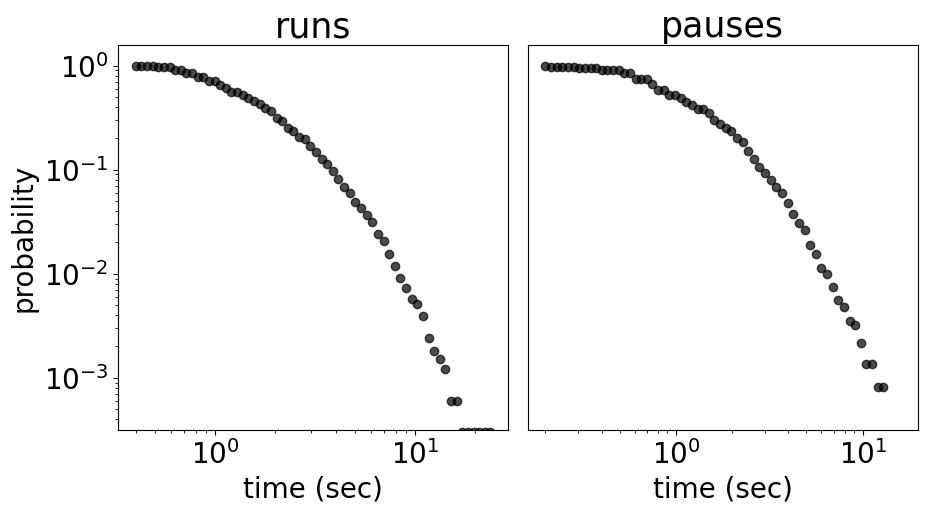

In [15]:
show("general")

## Section 6 : Watching the food disappear

The same experiment, rendered. The food grid is drawn in green and each cell fades towards white as
the larvae eat it, so the trails the animals leave behind are literally the food they consumed.

`fps` here is a playback speed rather than a frame count : one frame is written per simulation tick,
so the clip lasts `Nticks * dt / fps` seconds. At the default of 60 the ten simulated minutes would
be compressed into ten seconds; `VIDEO_SPEED = 20` gives a more watchable half minute.

In [16]:
if SAVE_VIDEO:
    # The rendered run is only wanted for its pixels, so it neither derives
    # metrics nor stores a second dataset. That roughly halves its cost.
    p_vid = reg.conf.Exp.expand(EXPERIMENT)
    p_vid.enrichment = {}

    r_vid = ExpRun(
        parameters=p_vid,
        N=N,
        store_data=False,
        screen_kws={
            "vis_mode": "video",
            "show_display": False,
            "save_video": True,
            "media_dir": MEDIA_DIR,
            "video_file": "food_grid_depletion",
            "fps": VIDEO_SPEED,
            "intro_text": False,
        },
    )
    r_vid.simulate()
    print(f"Video written to {MEDIA_DIR}/food_grid_depletion.mp4")
else:
    print("Set SAVE_VIDEO = True to render the depletion video.")

--- Simulation food_grid_21 initialized!--- 
--- Simulation food_grid_21 : Generating agent groups!--- 


Video will be saved as ./media/simulated_experiments/food_grid_depletion.mp4
Screen opened



Run time: 0:08:31.772140
Simulation finished
--- Simulation food_grid_21 completed in 512 seconds!--- 


Video written to ./media/simulated_experiments/food_grid_depletion.mp4


If you are running this notebook yourself, the file is playable straight from the media folder. The
grid starts uniformly green and ends mottled, with the pale patches marking where the animals spent
their time.

## What the paper reports

Feeding is the third sensorimotor primitive of the behavioral architecture in Sakagiannis et al.
(2025) - the *exploitation* branch of Figure 1A, mutually exclusive with crawling and gated by the
same intermittency module that produces runs and pauses during exploration.

The paper's own simulations stop at the reactive layer and do not include a feeding assay, so there
is no figure here to compare against. What this notebook demonstrates is the module in isolation :
the crawl-feed switch, its time budget, and the consumption it produces.

Two things follow from the deliberate absence of energetics :

- **Nothing constrains how much is eaten.** A real larva's intake feeds back on its behavior through
  hunger; here it does not. The exploration-exploitation balance is a fixed parameter rather than a
  state variable, which is exactly why this assay isolates the behavior.
- **There are no rover/sitter phenotypes.** Those differ in a DEB parameter, so they only mean
  something in the experiments that attach a Dynamic Energy Budget to the agent - `RvsS` and
  `growth` in the catalog.

## Where to go next

- [Free exploration](free_exploration.ipynb) - the same intermittency module with nothing to eat.
- [Building an environment](../4_models_and_environments/environment_configuration.ipynb) - how a
  food grid or discrete food patches are placed in an arena.
- Reference : [Arenas and substrates](../../agents_environments/arenas_and_substrates.md) and
  [Experiment types](../../concepts/experiment_types.md), which lists the feeding assays that do
  carry energetics.

## References

> Sakagiannis PP, Jürgensen AM, Nawrot MP. 2025. *A behavioral architecture for realistic
simulations of Drosophila larva locomotion and foraging.* eLife 14:RP104262.
<https://doi.org/10.7554/eLife.104262>

> Sakagiannis PP, Rapp H, Jovanic T, Nawrot MP. 2025. *Larvaworld: a behavioral simulation and
analysis platform for Drosophila larva.* bioRxiv.
<https://doi.org/10.1101/2025.06.15.659765>